<a href="https://colab.research.google.com/github/4GooseCrane3/Deep_Learning/blob/main/Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#1. Feedforward Neural Network (Single Hidden Layer) for Breast Cancer Classification
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score


def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    return z * (1 - z)

data = load_breast_cancer()
X = data.data
y = data.target.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

input_neurons = X_train.shape[1]
hidden_neurons = 12
output_neurons = 1

np.random.seed(42)
W1 = np.random.randn(input_neurons, hidden_neurons)
b1 = np.zeros((1, hidden_neurons))

W2 = np.random.randn(hidden_neurons, output_neurons)
b2 = np.zeros((1, output_neurons))

lr = 0.01
epochs = 2000


for _ in range(epochs):
    z1 = np.dot(X_train, W1) + b1
    a1 = sigmoid(z1)

    z2 = np.dot(a1, W2) + b2
    y_pred = sigmoid(z2)

    error = y_pred - y_train

    dW2 = np.dot(a1.T, error)
    db2 = np.sum(error, axis=0, keepdims=True)

    da1 = np.dot(error, W2.T)
    dz1 = da1 * sigmoid_derivative(a1)

    dW1 = np.dot(X_train.T, dz1)
    db1 = np.sum(dz1, axis=0, keepdims=True)

    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1


train_pred = sigmoid(np.dot(sigmoid(np.dot(X_train, W1) + b1), W2) + b2)
test_pred = sigmoid(np.dot(sigmoid(np.dot(X_test, W1) + b1), W2) + b2)

train_pred = (train_pred >= 0.5).astype(int)
test_pred = (test_pred >= 0.5).astype(int)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print(f"Training Accuracy: {train_acc * 100:.2f}%")
print(f"Testing Accuracy:  {test_acc * 100:.2f}%")

Training Accuracy: 100.00%
Testing Accuracy:  96.49%


In [ ]:
#2. Test Sample Predictions with Class Probabilities from a Trained Feedforward Neural Network
test_probs = sigmoid(
    np.dot(
        sigmoid(np.dot(X_test, W1) + b1),
        W2
    ) + b2
)

print("\nFirst 20 Test Predictions")
print("Idx | Actual | Predicted | Probability")
print("-" * 42)

for i in range(20):
    print(
        f"{i:3d} |"
        f"{int(y_test[i][0]):7d} |"
        f"{int(test_pred[i][0]):10d} |"
        f"{test_probs[i][0]:11.4f}"
    )


First 20 Test Predictions
Idx | Actual | Predicted | Probability
------------------------------------------
  0 |      1 |         1 |     0.9989
  1 |      0 |         0 |     0.0000
  2 |      0 |         0 |     0.0000
  3 |      1 |         1 |     1.0000
  4 |      1 |         1 |     1.0000
  5 |      0 |         0 |     0.0000
  6 |      0 |         0 |     0.0000
  7 |      0 |         0 |     0.0000
  8 |      1 |         0 |     0.1378
  9 |      1 |         1 |     1.0000
 10 |      1 |         1 |     0.9917
 11 |      0 |         0 |     0.0000
 12 |      1 |         1 |     0.9999
 13 |      0 |         0 |     0.0104
 14 |      1 |         1 |     1.0000
 15 |      0 |         0 |     0.0033
 16 |      1 |         1 |     1.0000
 17 |      1 |         1 |     1.0000
 18 |      1 |         1 |     1.0000
 19 |      0 |         0 |     0.0000


In [ ]:
#3. Single Neuron Perceptron with Sigmoid Activation Trained Using Gradient Descent for AND Gate Logic
import numpy as np


input_size = 2
learning_rate = 0.01
iterations = 3000
print_interval = 1000

# AND Gate Dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([[0], [0], [0], [1]])


np.random.seed(42)
weights = np.random.uniform(-1, 1, (input_size, 1))
bias = np.array([[0.0]])

print("Initial Weights and Bias")
print("Weights:", weights.flatten())
print("Bias:", bias[0, 0])


def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -250, 250)))

def sigmoid_derivative(x):
    return x * (1 - x)

def predict(X, weights, bias):
    return sigmoid(np.dot(X, weights) + bias)


print("\nTraining Single Neuron (AND Gate)...")

for iteration in range(iterations):
    linear_output = np.dot(X, weights) + bias
    output = sigmoid(linear_output)

    error = y - output
    d_output = error * sigmoid_derivative(output)

    weights += learning_rate * np.dot(X.T, d_output)
    bias += learning_rate * np.sum(d_output, axis=0, keepdims=True)

    loss = np.mean(np.abs(error))

    if iteration % print_interval == 0:
        print(f"Iteration {iteration}: Loss = {loss:.4f}")


print("\nTraining Complete!")
print(f"Final Weights: W1={weights[0,0]:.3f}, W2={weights[1,0]:.3f}")
print(f"Final Bias: {bias[0,0]:.3f}")

final_predictions = predict(X, weights, bias)

print("\nPredictions (AND Gate):")
for i in range(len(X)):
    pred_class = 1 if final_predictions[i, 0] > 0.5 else 0
    print(f"Input {X[i]} → {final_predictions[i,0]:.3f} ({pred_class})")

Initial Weights and Bias
Weights: [-0.25091976  0.90142861]
Bias: 0.0

Training Single Neuron (AND Gate)...
Iteration 0: Loss = 0.4979
Iteration 1000: Loss = 0.3525
Iteration 2000: Loss = 0.2996

Training Complete!
Final Weights: W1=1.315, W2=1.454
Final Bias: -2.272

Predictions (AND Gate):
Input [0 0] → 0.093 (0)
Input [0 1] → 0.306 (0)
Input [1 0] → 0.277 (0)
Input [1 1] → 0.622 (1)


In [ ]:
#4. Single Neuron with Sigmoid Activation Trained via Gradient Descent for OR Gate Classification
import numpy as np

# OR Gate Dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([[0], [1], [1], [1]])


learning_rate = 0.01
iterations = 3000

np.random.seed(42)
weights = np.random.uniform(-1, 1, (2, 1))
bias = np.array([[0.0]])

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -250, 250)))

def sigmoid_derivative(x):
    return x * (1 - x)

print("\nTraining OR Gate (Sigmoid)...")

for iteration in range(iterations):
    linear_output = np.dot(X, weights) + bias
    output = sigmoid(linear_output)

    error = y - output
    d_output = error * sigmoid_derivative(output)

    weights += learning_rate * np.dot(X.T, d_output)
    bias += learning_rate * np.sum(d_output, axis=0, keepdims=True)

    if iteration % 1000 == 0:
        loss = np.mean(np.abs(error))
        print(f"Iteration {iteration}: Loss = {loss:.4f}")

print("\nPredictions (OR Gate - Sigmoid):")
for i in range(len(X)):
    pred = 1 if output[i, 0] > 0.5 else 0
    print(f"Input {X[i]} → {output[i,0]:.3f} ({pred})")


Training OR Gate (Sigmoid)...
Iteration 0: Loss = 0.4235
Iteration 1000: Loss = 0.2693
Iteration 2000: Loss = 0.2290

Predictions (OR Gate - Sigmoid):
Input [0 0] → 0.370 (0)
Input [0 1] → 0.821 (1)
Input [1 0] → 0.784 (1)
Input [1 1] → 0.966 (1)


In [ ]:
#5. Two-Layer Feedforward Neural Network with Backpropagation to Solve the XOR Gate Problem
import numpy as np

# XOR Dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([[0], [1], [1], [0]])


learning_rate = 0.1
epochs = 10000

np.random.seed(42)

# Weights and biases
W1 = np.random.uniform(-1, 1, (2, 2))
b1 = np.zeros((1, 2))

W2 = np.random.uniform(-1, 1, (2, 1))
b2 = np.zeros((1, 1))


def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -250, 250)))

def sigmoid_derivative(x):
    return x * (1 - x)

print("Training XOR Gate (2-Layer Neural Network)...")

for epoch in range(epochs):
    # Forward pass
    hidden_input = np.dot(X, W1) + b1
    hidden_output = sigmoid(hidden_input)

    final_input = np.dot(hidden_output, W2) + b2
    output = sigmoid(final_input)
    error = y - output

    d_output = error * sigmoid_derivative(output)
    d_hidden = np.dot(d_output, W2.T) * sigmoid_derivative(hidden_output)
    W2 += learning_rate * np.dot(hidden_output.T, d_output)
    b2 += learning_rate * np.sum(d_output, axis=0, keepdims=True)

    W1 += learning_rate * np.dot(X.T, d_hidden)
    b1 += learning_rate * np.sum(d_hidden, axis=0, keepdims=True)

    if epoch % 2000 == 0:
        loss = np.mean(np.abs(error))
        print(f"Epoch {epoch}: Loss = {loss:.4f}")


print("\nPredictions (XOR Gate):")
for i in range(len(X)):
    pred = 1 if output[i, 0] > 0.5 else 0
    print(f"Input {X[i]} → {output[i,0]:.3f} ({pred})")

Training XOR Gate (2-Layer Neural Network)...
Epoch 0: Loss = 0.5005
Epoch 2000: Loss = 0.4998
Epoch 4000: Loss = 0.4985
Epoch 6000: Loss = 0.4200
Epoch 8000: Loss = 0.1565

Predictions (XOR Gate):
Input [0 0] → 0.096 (0)
Input [0 1] → 0.894 (1)
Input [1 0] → 0.894 (1)
Input [1 1] → 0.086 (0)


In [ ]:
#6. Binary Classification Using a Multi-Layer Perceptron (MLP) with Sigmoid Activation
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_classes=2,
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = MLPClassifier(
    hidden_layer_sizes=(12,),
    activation='logistic',
    max_iter=1000,
    random_state=42
)
model.fit(X_train, y_train)
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)
train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.8675
Testing Accuracy: 0.83


In [ ]:
#7. Breast Cancer Classification Using a Multi-Layer Perceptron (MLP) Neural Network with Sigmoid Activation
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
data = load_breast_cancer()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = MLPClassifier(
    hidden_layer_sizes=(12,),
    activation='logistic',
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)
print("MLP Training Accuracy:",
      accuracy_score(y_train, train_pred))
print("MLP Testing Accuracy:",
      accuracy_score(y_test, test_pred))

MLP Training Accuracy: 0.9340659340659341
MLP Testing Accuracy: 0.9649122807017544


In [ ]:
#8. AND Gate Hardcoded Weights (Single Neuron)
import numpy as np

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

def step(x):
    return 1 if x >= 0 else 0

# Hardcoded weights & bias
weights = np.array([1, 1])
bias = -1.5

print("AND Gate (Hardcoded Weights)")
for x in X:
    y = step(np.dot(x, weights) + bias)
    print(f"Input {x} → {y}")


AND Gate (Hardcoded Weights)
Input [0 0] → 0
Input [0 1] → 0
Input [1 0] → 0
Input [1 1] → 1


In [ ]:
#9.OR Gate Hardcoded Weights (Single Neuron)
import numpy as np

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

def step(x):
    return 1 if x >= 0 else 0

# Hardcoded weights & bias
weights = np.array([1, 1])
bias = -0.5

print("OR Gate (Hardcoded Weights)")
for x in X:
    y = step(np.dot(x, weights) + bias)
    print(f"Input {x} → {y}")


OR Gate (Hardcoded Weights)
Input [0 0] → 0
Input [0 1] → 1
Input [1 0] → 1
Input [1 1] → 1


In [ ]:
#10. XOR Gate Hardcoded Weights (2-Layer Network)
import numpy as np

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

def step(x):
    return 1 if x >= 0 else 0

# Hidden layer (2 neurons) — hardcoded
W1 = np.array([
    [1, -1],
    [1, -1]
])
b1 = np.array([-0.5, 1.5])

# Output layer — hardcoded
W2 = np.array([1, 1])
b2 = -1.5

print("XOR Gate (Hardcoded Weights)")
for x in X:
    h = [step(np.dot(x, W1[:, i]) + b1[i]) for i in range(2)]
    y = step(np.dot(h, W2) + b2)
    print(f"Input {x} → {y}")


XOR Gate (Hardcoded Weights)
Input [0 0] → 0
Input [0 1] → 1
Input [1 0] → 1
Input [1 1] → 0


In [ ]:
#11. Ridge Regression
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=100, n_features=5, noise=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

print("Ridge Regression Coefficients:", ridge.coef_)
print("Ridge Regression R2 Score:", ridge.score(X_test, y_test))


Ridge Regression Coefficients: [60.80641691 96.97650095 59.85083263 54.82588222 35.69887237]
Ridge Regression R2 Score: 0.994006040552328


In [ ]:
#12. Lasso Regression
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=100, n_features=5, noise=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

print("Lasso Regression Coefficients:", lasso.coef_)
print("Lasso Regression R2 Score:", lasso.score(X_test, y_test))


Lasso Regression Coefficients: [61.43821843 98.34755587 60.9358236  55.43964642 35.89008021]
Lasso Regression R2 Score: 0.9944057177924089


In [ ]:
#13. Mini-Batch Gradient Descent for AND Gate
import numpy as np
import matplotlib.pyplot as plt

# AND gate dataset
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])
y = np.array([[0],
              [0],
              [0],
              [1]])

# Hyperparameters
learning_rate = 0.1
epochs = 1000
batch_size = 2

# Initialize parameters
np.random.seed(1)
weights = np.random.randn(2, 1)
bias = 0.0

loss_history = []

# Sigmoid activation
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Binary Cross Entropy Loss
def binary_cross_entropy(y_true, y_pred):
    eps = 1e-9
    return -np.mean(y_true * np.log(y_pred + eps) +
                     (1 - y_true) * np.log(1 - y_pred + eps))

# Training
for epoch in range(epochs):

    # Shuffle data for mini-batch
    indices = np.random.permutation(len(X))
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    for i in range(0, len(X), batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        # Forward pass
        z = np.dot(X_batch, weights) + bias
        y_pred = sigmoid(z)

        # Backpropagation
        error = y_pred - y_batch
        dw = np.dot(X_batch.T, error) / batch_size
        db = np.mean(error)

        # Update parameters
        weights -= learning_rate * dw
        bias -= learning_rate * db

    # Compute loss
    full_output = sigmoid(np.dot(X, weights) + bias)
    loss = binary_cross_entropy(y, full_output)
    loss_history.append(loss)

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Loss = {loss:.4f}")

# Final predictions
final_output = sigmoid(np.dot(X, weights) + bias)
predicted = (final_output >= 0.5).astype(int)

print("\nACTUAL vs PREDICTED (Mini-Batch GD)")
for i in range(len(X)):
    print(f"Input {X[i]} | Actual: {y[i][0]} | "
          f"Predicted: {predicted[i][0]} "
          f"(value = {final_output[i][0]:.3f})")




Epoch 0 | Loss = 0.7823
Epoch 500 | Loss = 0.1385

ACTUAL vs PREDICTED (Mini-Batch GD)
Input [0 0] | Actual: 0 | Predicted: 0 (value = 0.001)
Input [0 1] | Actual: 0 | Predicted: 0 (value = 0.088)
Input [1 0] | Actual: 0 | Predicted: 0 (value = 0.089)
Input [1 1] | Actual: 1 | Predicted: 1 (value = 0.876)


In [ ]:
#14. Stochastic Gradient Descent (SGD) for AND Gate
import numpy as np
import matplotlib.pyplot as plt

# AND gate dataset
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])
y = np.array([[0],
              [0],
              [0],
              [1]])

# Hyperparameters
learning_rate = 0.1
epochs = 1000

# Initialize parameters
np.random.seed(1)
weights = np.random.randn(2, 1)
bias = 0.0

loss_history = []

# Sigmoid activation function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Binary Cross Entropy Loss
def binary_cross_entropy(y_true, y_pred):
    eps = 1e-9
    return -np.mean(
        y_true * np.log(y_pred + eps) +
        (1 - y_true) * np.log(1 - y_pred + eps)
    )

# Training using SGD
for epoch in range(epochs):
    for i in range(len(X)):
        xi = X[i].reshape(1, -1)
        yi = y[i]

        z = np.dot(xi, weights) + bias
        y_pred = sigmoid(z)

        error = y_pred - yi
        dw = np.dot(xi.T, error)
        db = error[0, 0]

        weights -= learning_rate * dw
        bias -= learning_rate * db

    full_output = sigmoid(np.dot(X, weights) + bias)
    loss = binary_cross_entropy(y, full_output)
    loss_history.append(loss)

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Loss = {loss:.4f}")

# Final predictions
final_output = sigmoid(np.dot(X, weights) + bias)
predicted = (final_output >= 0.5).astype(int)

print("\nACTUAL vs PREDICTED (SGD)")
for i in range(len(X)):
    print(f"Input {X[i]} | Actual: {y[i][0]} | "
          f"Predicted: {predicted[i][0]} "
          f"(value = {final_output[i][0]:.3f})")



Epoch 0 | Loss = 0.7580
Epoch 500 | Loss = 0.0788

ACTUAL vs PREDICTED (SGD)
Input [0 0] | Actual: 0 | Predicted: 0 (value = 0.000)
Input [0 1] | Actual: 0 | Predicted: 0 (value = 0.048)
Input [1 0] | Actual: 0 | Predicted: 0 (value = 0.049)
Input [1 1] | Actual: 1 | Predicted: 1 (value = 0.933)


In [ ]:
#15. Gradient Descent with Momentum for AND Gate
import numpy as np
import matplotlib.pyplot as plt

# AND gate dataset
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])
y = np.array([[0],
              [0],
              [0],
              [1]])

# Hyperparameters
learning_rate = 0.1
epochs = 1000
beta = 0.9

# Initialize parameters
np.random.seed(1)
weights = np.random.randn(2, 1)
bias = 0.0

# Initialize momentum terms
velocity_w = np.zeros_like(weights)
velocity_b = 0.0

loss_history = []

# Sigmoid activation function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Binary Cross Entropy Loss
def binary_cross_entropy(y_true, y_pred):
    eps = 1e-9
    return -np.mean(
        y_true * np.log(y_pred + eps) +
        (1 - y_true) * np.log(1 - y_pred + eps)
    )

# Training loop
for epoch in range(epochs):

    z = np.dot(X, weights) + bias
    y_pred = sigmoid(z)

    error = y_pred - y
    grad_w = np.dot(X.T, error)
    grad_b = np.sum(error)

    velocity_w = beta * velocity_w + learning_rate * grad_w
    velocity_b = beta * velocity_b + learning_rate * grad_b

    weights -= velocity_w
    bias -= velocity_b

    loss = binary_cross_entropy(y, y_pred)
    loss_history.append(loss)

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Loss = {loss:.4f}")

# Final predictions
final_output = sigmoid(np.dot(X, weights) + bias)
predicted = (final_output >= 0.5).astype(int)

print("\nACTUAL vs PREDICTED (Momentum GD)")
for i in range(len(X)):
    print(f"Input {X[i]} | Actual: {y[i][0]} | "
          f"Predicted: {predicted[i][0]} "
          f"(value = {final_output[i][0]:.3f})")




Epoch 0 | Loss = 0.8101
Epoch 500 | Loss = 0.0080

ACTUAL vs PREDICTED (Momentum GD)
Input [0 0] | Actual: 0 | Predicted: 0 (value = 0.000)
Input [0 1] | Actual: 0 | Predicted: 0 (value = 0.005)
Input [1 0] | Actual: 0 | Predicted: 0 (value = 0.005)
Input [1 1] | Actual: 1 | Predicted: 1 (value = 0.993)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
#lenet
def LeNet5(input_shape=(32, 32, 1), num_classes=10):
    model = models.Sequential()

    model.add(layers.Conv2D(6, kernel_size=5, activation='tanh', input_shape=input_shape))

    model.add(layers.AveragePooling2D(pool_size=2, strides=2))

    model.add(layers.Conv2D(16, kernel_size=5, activation='tanh'))

    model.add(layers.AveragePooling2D(pool_size=2, strides=2))

    model.add(layers.Flatten())
    model.add(layers.Dense(120, activation='tanh'))

    model.add(layers.Dense(84, activation='tanh'))

    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

lenet = LeNet5()
lenet.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#17. alexnet
def AlexNet(input_shape=(227, 227, 3), num_classes=1000):
    model = models.Sequential()

    # Layer 1
    model.add(layers.Conv2D(96, (11, 11), strides=4, activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D(pool_size=3, strides=2))

    # Layer 2
    model.add(layers.Conv2D(256, (5, 5), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=3, strides=2))

    # Layer 3
    model.add(layers.Conv2D(384, (3, 3), padding='same', activation='relu'))

    # Layer 4
    model.add(layers.Conv2D(384, (3, 3), padding='same', activation='relu'))

    # Layer 5
    model.add(layers.Conv2D(256, (3, 3), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=3, strides=2))

    # Fully Connected Layers
    model.add(layers.Flatten())
    model.add(layers.Dense(4096, activation='relu'))
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(4096, activation='relu'))
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

alexnet = AlexNet()
alexnet.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,378,344 (237.95 MB)

 Trainable params: 62,378,344 (237.95 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#18. vgg 19
def VGG19(input_shape=(224, 224, 3), num_classes=1000):
    model = models.Sequential()

    # Block 1
    model.add(layers.Conv2D(64, 3, padding='same', activation='relu', input_shape=input_shape))
    model.add(layers.Conv2D(64, 3, padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(2, 2))

    # Block 2
    model.add(layers.Conv2D(128, 3, padding='same', activation='relu'))
    model.add(layers.Conv2D(128, 3, padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(2, 2))

    # Block 3
    model.add(layers.Conv2D(256, 3, padding='same', activation='relu'))
    model.add(layers.Conv2D(256, 3, padding='same', activation='relu'))
    model.add(layers.Conv2D(256, 3, padding='same', activation='relu'))
    model.add(layers.Conv2D(256, 3, padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(2, 2))

    # Block 4
    model.add(layers.Conv2D(512, 3, padding='same', activation='relu'))
    model.add(layers.Conv2D(512, 3, padding='same', activation='relu'))
    model.add(layers.Conv2D(512, 3, padding='same', activation='relu'))
    model.add(layers.Conv2D(512, 3, padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(2, 2))

    # Block 5
    model.add(layers.Conv2D(512, 3, padding='same', activation='relu'))
    model.add(layers.Conv2D(512, 3, padding='same', activation='relu'))
    model.add(layers.Conv2D(512, 3, padding='same', activation='relu'))
    model.add(layers.Conv2D(512, 3, padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(2, 2))

    # Fully Connected
    model.add(layers.Flatten())
    model.add(layers.Dense(4096, activation='relu'))
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(4096, activation='relu'))
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

vgg19 = VGG19()
vgg19.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4096)           │    16,781,31

 Total params: 143,667,240 (548.05 MB)

 Trainable params: 143,667,240 (548.05 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np

# Input combinations
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Step activation function
def step(x):
    return 1 if x >= 0 else 0

# Hardcoded weights and bias
weights = np.array([1, 1])
bias = -0.5

print("OR Gate")

for x in X:
    z = np.dot(x, weights) + bias
    y = step(z)
    print("Input:", x, "Output:", y)


OR Gate
Input: [0 0] Output: 0
Input: [0 1] Output: 1
Input: [1 0] Output: 1
Input: [1 1] Output: 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 44s 43ms/step - accuracy: 0.8614 - loss: 0.4772
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 36s 39ms/step - accuracy: 0.9656 - loss: 0.1122
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 43s 41ms/step - accuracy: 0.9785 - loss: 0.0701
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 39s 38ms/step - accuracy: 0.9840 - loss: 0.0498
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 37ms/step - accuracy: 0.9893 - loss: 0.0348
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9806 - loss: 0.0541
Test Accuracy: 0.984499990940094
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


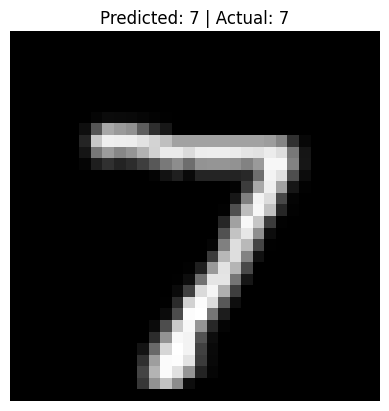

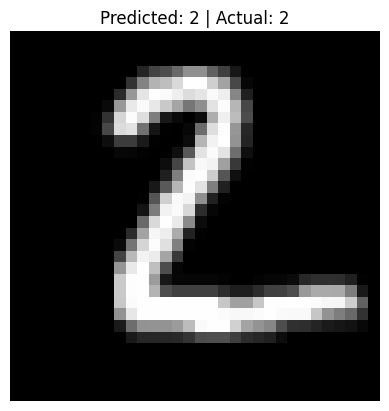

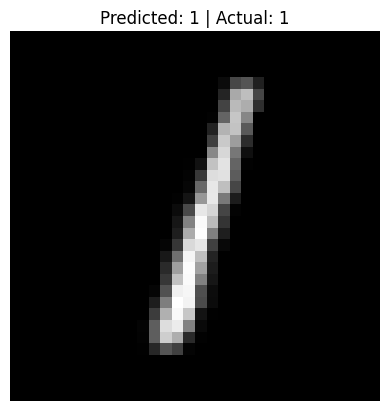

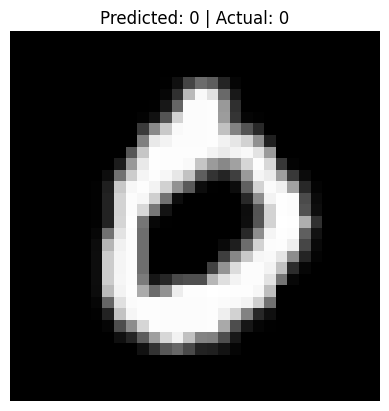

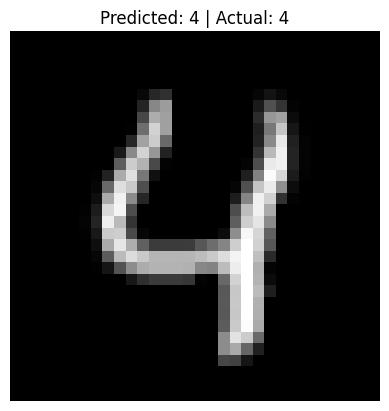

In [ ]:
#LENET
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

model = models.Sequential([
    layers.Conv2D(6, 5, activation='tanh', input_shape=(32,32,1)),
    layers.AveragePooling2D(pool_size=(2,2)),
    layers.Conv2D(16, 5, activation='tanh'),
    layers.AveragePooling2D(pool_size=(2,2)),
    layers.Flatten(),
    layers.Dense(120, activation='tanh'),
    layers.Dense(84, activation='tanh'),
    layers.Dense(10, activation='softmax')
])

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = tf.image.resize(x_train[...,None], (32,32))/255.0
x_test = tf.image.resize(x_test[...,None], (32,32))/255.0

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(x_train, y_train, epochs=5, batch_size=64)

loss, acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", acc)

pred = model.predict(x_test)
labels = np.argmax(pred, axis=1)

for i in range(5):
    plt.imshow(x_test[i].numpy().squeeze(), cmap='gray')
    plt.title(f"Predicted: {labels[i]} | Actual: {y_test[i]}")
    plt.axis('off')
    plt.show()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - accuracy: 0.5461 - loss: 0.6823 - val_accuracy: 0.7204 - val_loss: 0.5490
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step - accuracy: 0.7205 - loss: 0.5757 - val_accuracy: 0.5658 - val_loss: 0.7745
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.7259 - loss: 0.5384 - val_accuracy: 0.7908 - val_loss: 0.4621
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.8469 - loss: 0.3577 - val_accuracy: 0.8078 - val_loss: 0.4519
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.8909 - loss: 0.2801 - val_accuracy: 0.7974 - val_loss: 0.4817
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.7992 - loss: 0.4829
Test Accuracy: 0.8008400201797485


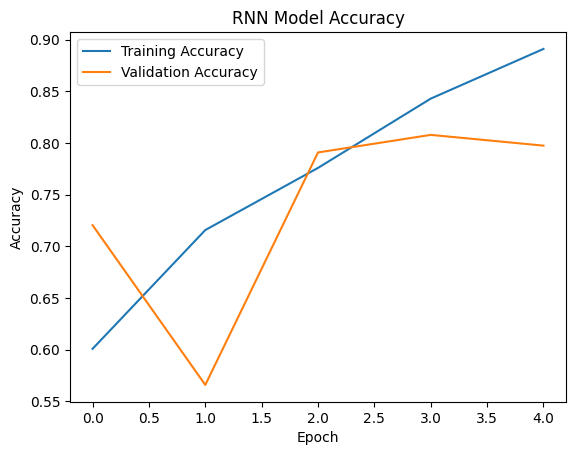

In [ ]:
############
# RNN for Text classification
############

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
import matplotlib.pyplot as plt

vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

max_length = 200
x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

model = Sequential()

model.add(Embedding(input_dim=vocab_size, output_dim=32, input_length=max_length))
model.add(SimpleRNN(32))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

loss, accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", accuracy)

plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RNN Model Accuracy")
plt.show()

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 62s 173ms/step - accuracy: 0.7030 - loss: 0.5389 - val_accuracy: 0.8370 - val_loss: 0.3763
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 168ms/step - accuracy: 0.8980 - loss: 0.2683 - val_accuracy: 0.8802 - val_loss: 0.3153
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 167ms/step - accuracy: 0.9298 - loss: 0.1878 - val_accuracy: 0.8726 - val_loss: 0.3154
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 165ms/step - accuracy: 0.9525 - loss: 0.1361 - val_accuracy: 0.8682 - val_loss: 0.3405
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 164ms/step - accuracy: 0.9640 - loss: 0.1001 - val_accuracy: 0.8578 - val_loss: 0.4974
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.8517 - loss: 0.5066
Test Accuracy: 0.8502399921417236


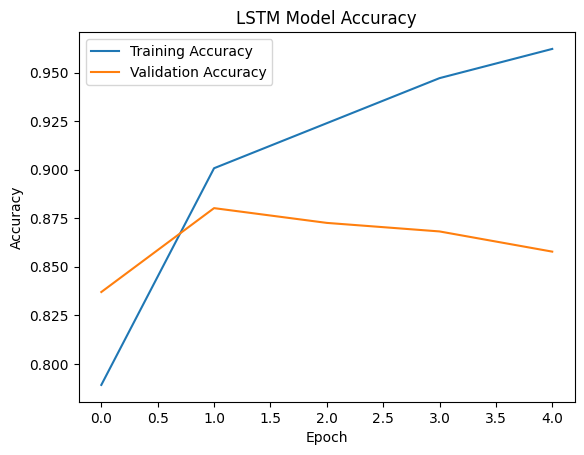

In [ ]:
############
# LSTM for Text classification
############

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
import matplotlib.pyplot as plt

vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

max_length = 200
x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

model = Sequential()

model.add(Embedding(input_dim=vocab_size, output_dim=64, input_length=max_length))
model.add(LSTM(64))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

loss, accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", accuracy)

plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Model Accuracy")
plt.show()

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 65s 201ms/step - accuracy: 0.6628 - loss: 0.5637 - val_accuracy: 0.8544 - val_loss: 0.3436
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 199ms/step - accuracy: 0.8915 - loss: 0.2668 - val_accuracy: 0.8774 - val_loss: 0.3298
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 63s 201ms/step - accuracy: 0.9346 - loss: 0.1734 - val_accuracy: 0.8570 - val_loss: 0.3586
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 202ms/step - accuracy: 0.9556 - loss: 0.1232 - val_accuracy: 0.8624 - val_loss: 0.3702
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 199ms/step - accuracy: 0.9735 - loss: 0.0795 - val_accuracy: 0.8648 - val_loss: 0.4294
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.8578 - loss: 0.4580
Test Accuracy: 0.8584799766540527


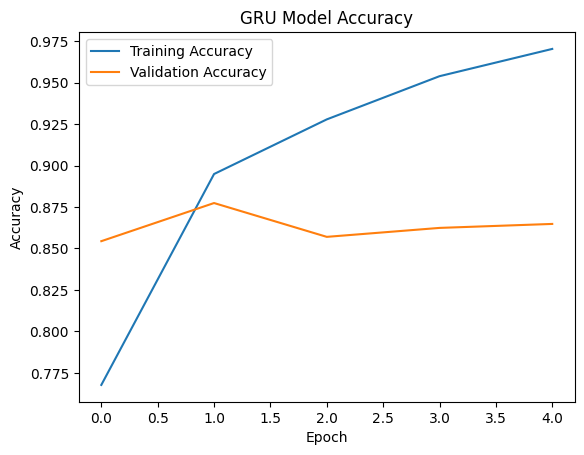

In [ ]:
############
# GRU for Text classification
############

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense
import matplotlib.pyplot as plt

vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

max_length = 200
x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

model = Sequential()

model.add(Embedding(input_dim=vocab_size, output_dim=64, input_length=max_length))
model.add(GRU(64))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

loss, accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", accuracy)

plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GRU Model Accuracy")
plt.show()